# JP Morgan Chase — AI Finance Agent
## Lab 02 : Exploratory Data Analysis (EDA)
**Author :** Fabrice William FOMHOM  
**Date :** March 2026  
**Objective :** Analyze transaction patterns, identify fraud signals, 
and produce executive-ready visualizations

## Business Questions We Answer
1. What is the monthly transaction volume and fraud trend?
2. Which categories and merchants have the highest fraud rate?
3. What does a fraudulent transaction look like vs a normal one?
4. Which customers are highest risk?

In [1]:
# ============================================================
# JP Morgan Chase — Lab 02 : EDA
# Step 1 : Import libraries and load dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# Project paths
BASE_DIR = r"C:\Users\HP\jpmorgan_finance_agent"
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

# Load the dataset we created in Lab 01
df = pd.read_csv(os.path.join(DATA_DIR, "jpmorgan_transactions.csv"),
                 parse_dates=["date"])

print(f"✅ Dataset loaded : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Date range     : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"   Fraud rate     : {df['is_fraud'].mean()*100:.2f}%")

✅ Dataset loaded : 1000 rows × 11 columns
   Date range     : 2024-01-03 → 2024-12-31
   Fraud rate     : 2.90%


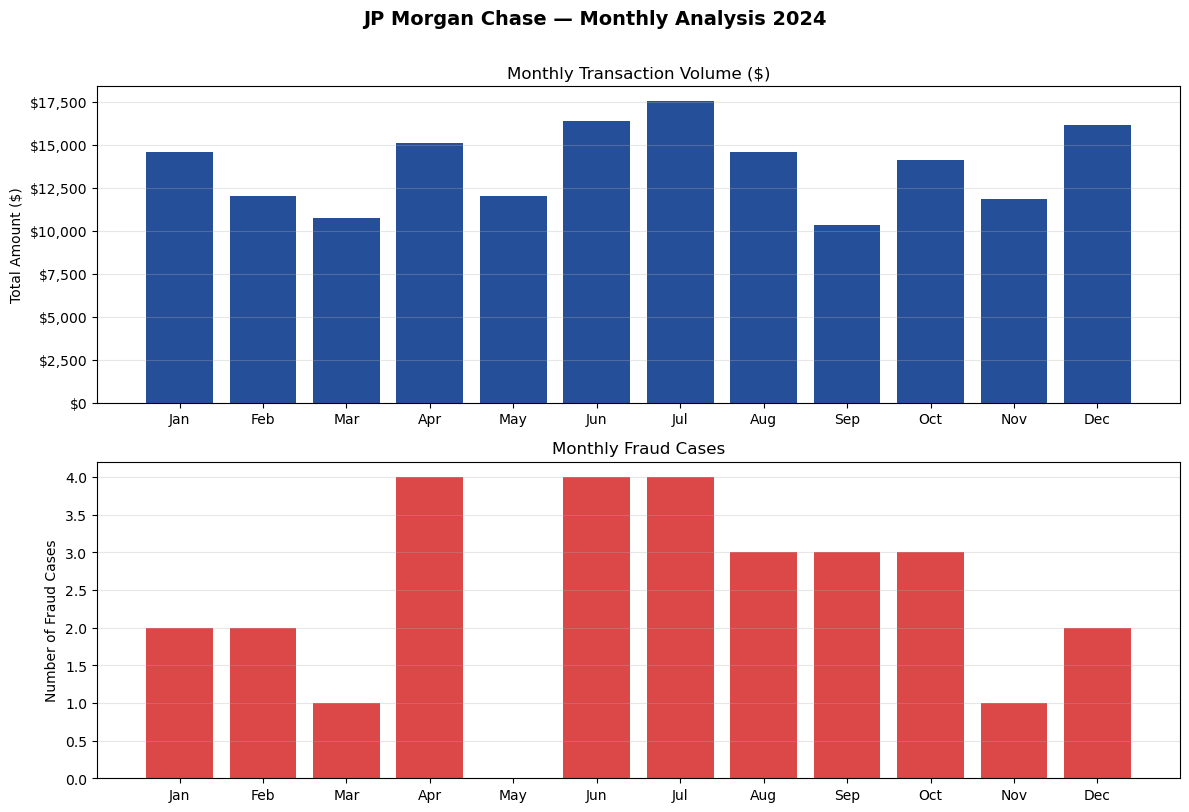

✅ Chart saved : C:\Users\HP\jpmorgan_finance_agent\outputs\01_monthly_analysis.png

Monthly Summary :
            total_transactions  total_amount  fraud_cases
month_name                                               
Jan                         69      14547.33            2
Feb                         80      12008.02            2
Mar                         78      10760.65            1
Apr                         74      15112.25            4
May                         83      12037.77            0
Jun                         74      16381.94            4
Jul                        101      17509.98            4
Aug                         93      14557.12            3
Sep                         69      10353.14            3
Oct                         83      14100.17            3
Nov                         87      11841.31            1
Dec                        109      16155.85            2


In [2]:
# ============================================================
# Step 2 : Monthly Transaction Volume & Fraud Trend
# Business Question : Which months are busiest? When is fraud highest?
# ============================================================

# Group by month
monthly = df.groupby("month_name").agg(
    total_transactions = ("transaction_id", "count"),
    total_amount       = ("amount", "sum"),
    fraud_cases        = ("is_fraud", "sum")
).reindex(["Jan","Feb","Mar","Apr","May","Jun",
           "Jul","Aug","Sep","Oct","Nov","Dec"])

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle("JP Morgan Chase — Monthly Analysis 2024", 
             fontsize=14, fontweight="bold", y=1.01)

# Chart 1 : Transaction volume
axes[0].bar(monthly.index, monthly["total_amount"], 
            color="#003087", alpha=0.85)
axes[0].set_title("Monthly Transaction Volume ($)")
axes[0].set_ylabel("Total Amount ($)")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].grid(axis="y", alpha=0.3)

# Chart 2 : Fraud cases
axes[1].bar(monthly.index, monthly["fraud_cases"], 
            color="#D62728", alpha=0.85)
axes[1].set_title("Monthly Fraud Cases")
axes[1].set_ylabel("Number of Fraud Cases")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save chart
chart_path = os.path.join(OUTPUT_DIR, "01_monthly_analysis.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Chart saved : {chart_path}")
print(f"\nMonthly Summary :")
print(monthly.to_string())

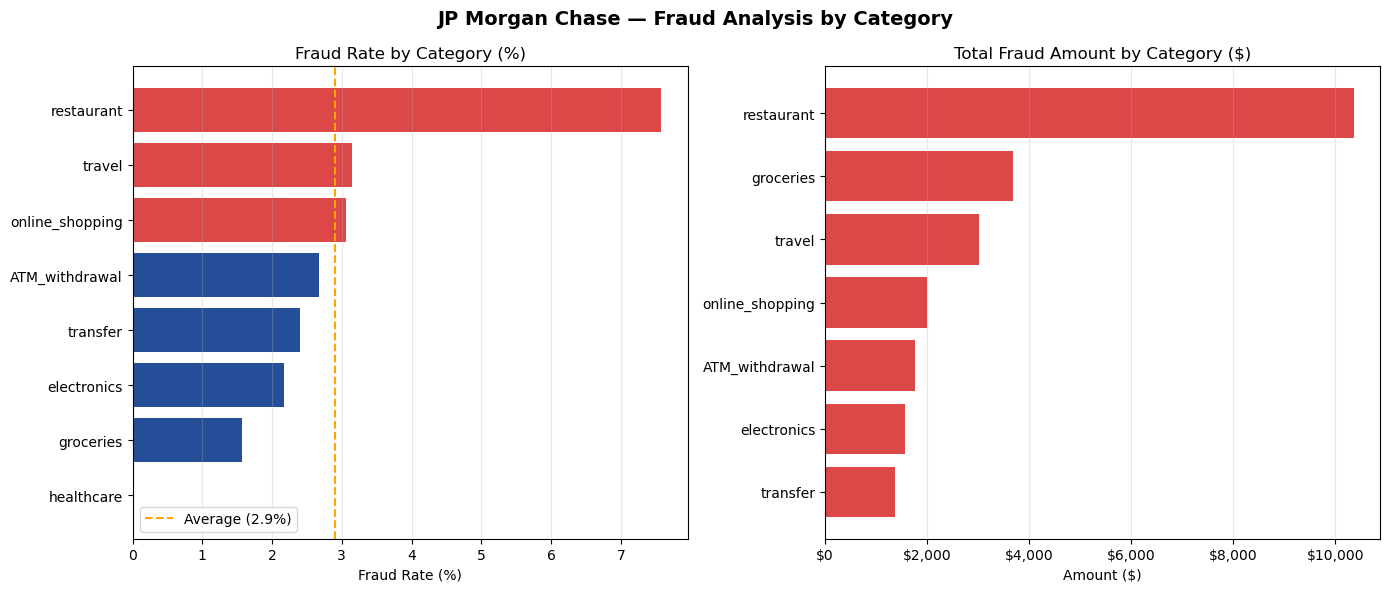

✅ Chart saved : C:\Users\HP\jpmorgan_finance_agent\outputs\02_fraud_by_category.png

Category Analysis :
                 total  fraud_cases  fraud_rate
category                                       
healthcare         108            0    0.000000
groceries          127            2    1.574803
electronics        138            3    2.173913
transfer           125            3    2.400000
ATM_withdrawal     112            3    2.678571
online_shopping    131            4    3.053435
travel             127            4    3.149606
restaurant         132           10    7.575758


In [3]:
# ============================================================
# Step 3 : Fraud Rate by Category
# Business Question : Which spending category hides the most fraud?
# ============================================================

# Calculate fraud rate per category
category_analysis = df.groupby("category").agg(
    total        = ("is_fraud", "count"),
    fraud_cases  = ("is_fraud", "sum"),
    total_amount = ("amount", "sum")
)
category_analysis["fraud_rate"] = (
    category_analysis["fraud_cases"] / category_analysis["total"] * 100
)
category_analysis = category_analysis.sort_values("fraud_rate", ascending=True)

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("JP Morgan Chase — Fraud Analysis by Category",
             fontsize=14, fontweight="bold")

# Chart 1 : Fraud rate %
colors = ["#D62728" if x > 3 else "#003087" 
          for x in category_analysis["fraud_rate"]]

axes[0].barh(category_analysis.index, 
             category_analysis["fraud_rate"],
             color=colors, alpha=0.85)
axes[0].set_title("Fraud Rate by Category (%)")
axes[0].set_xlabel("Fraud Rate (%)")
axes[0].axvline(x=2.9, color="orange", linestyle="--", 
                label="Average (2.9%)")
axes[0].legend()
axes[0].grid(axis="x", alpha=0.3)

# Chart 2 : Total fraud amount
category_fraud = df[df["is_fraud"]==1].groupby("category")["amount"].sum()
category_fraud = category_fraud.sort_values(ascending=True)

axes[1].barh(category_fraud.index, category_fraud.values,
             color="#D62728", alpha=0.85)
axes[1].set_title("Total Fraud Amount by Category ($)")
axes[1].set_xlabel("Amount ($)")
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()

# Save
chart_path = os.path.join(OUTPUT_DIR, "02_fraud_by_category.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Chart saved : {chart_path}")
print(f"\nCategory Analysis :")
print(category_analysis[["total","fraud_cases","fraud_rate"]].to_string())

TRANSACTION PROFILE : FRAUD vs NORMAL
Metric                          Normal        Fraud
-------------------------------------------------------
Count                              971           29
Average ($)                     145.86       818.51
Median ($)                      103.15       677.81
Std Dev ($)                     146.31       825.61
Min ($)                           0.70        40.59
Max ($)                        1225.87      3882.53


C:\Users\HP\AppData\Local\Temp\ipykernel_34368\838656589.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([normal_txns, fraud_txns],


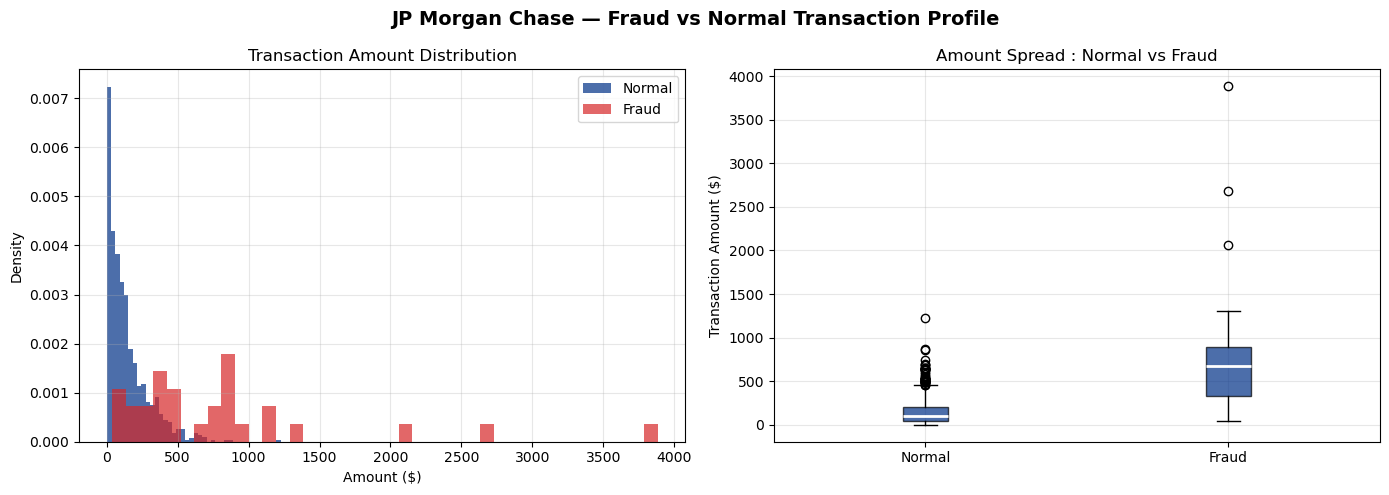

✅ Chart saved : C:\Users\HP\jpmorgan_finance_agent\outputs\03_fraud_vs_normal.png


In [4]:
# ============================================================
# Step 4 : Fraud vs Normal — Transaction Profile
# Business Question : What does a fraudulent transaction look like?
# ============================================================

fraud_txns  = df[df["is_fraud"] == 1]["amount"]
normal_txns = df[df["is_fraud"] == 0]["amount"]

print("=" * 55)
print("TRANSACTION PROFILE : FRAUD vs NORMAL")
print("=" * 55)
print(f"{'Metric':<25} {'Normal':>12} {'Fraud':>12}")
print("-" * 55)
print(f"{'Count':<25} {len(normal_txns):>12,} {len(fraud_txns):>12,}")
print(f"{'Average ($)':<25} {normal_txns.mean():>12.2f} {fraud_txns.mean():>12.2f}")
print(f"{'Median ($)':<25} {normal_txns.median():>12.2f} {fraud_txns.median():>12.2f}")
print(f"{'Std Dev ($)':<25} {normal_txns.std():>12.2f} {fraud_txns.std():>12.2f}")
print(f"{'Min ($)':<25} {normal_txns.min():>12.2f} {fraud_txns.min():>12.2f}")
print(f"{'Max ($)':<25} {normal_txns.max():>12.2f} {fraud_txns.max():>12.2f}")
print("=" * 55)

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("JP Morgan Chase — Fraud vs Normal Transaction Profile",
             fontsize=14, fontweight="bold")

# Chart 1 : Amount distribution
axes[0].hist(normal_txns, bins=40, color="#003087", 
             alpha=0.7, label="Normal", density=True)
axes[0].hist(fraud_txns,  bins=40, color="#D62728", 
             alpha=0.7, label="Fraud",  density=True)
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Chart 2 : Box plot comparison
axes[1].boxplot([normal_txns, fraud_txns],
                labels=["Normal", "Fraud"],
                patch_artist=True,
                boxprops=dict(facecolor="#003087", alpha=0.7),
                medianprops=dict(color="white", linewidth=2))
axes[1].set_title("Amount Spread : Normal vs Fraud")
axes[1].set_ylabel("Transaction Amount ($)")
axes[1].grid(alpha=0.3)

plt.tight_layout()

chart_path = os.path.join(OUTPUT_DIR, "03_fraud_vs_normal.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Chart saved : {chart_path}")